In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/ML_datasets/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
data.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
data.duplicated().sum()

np.int64(0)

In the dataset the TotalCharges column has float values but is labelled as categorical data so we need to fix this

In [ ]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
missing_values = data['TotalCharges'].isna().sum()
print(f'The number of missing values in the TotalCharges column: {missing_values}')

The number of missing values in the TotalCharges column: 11


In [ ]:
data.shape

(7043, 21)

In [ ]:
data['TotalCharges'] = data['TotalCharges'].fillna(0)
print(data['TotalCharges'].isna().sum())

0


In [ ]:
#Encode the data of our target column
data['Churn']=data['Churn'].map({'Yes':1, 'No':0})
print(data['Churn'].value_counts(normalize=True))

Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split

X = data.drop('Churn',axis=1)
y = data['Churn']

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2,random_state=42,stratify=y)

print(f'Training shape:{X_train.shape}')
print(f'\nTest shape:{X_test.shape}')
print('\nTarget distribution in Train set:')
print(y_train.value_counts(normalize=True))

Training shape:(5634, 20)

Test shape:(1409, 20)

Target distribution in Train set:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

#We will drop CustomerId column beacuse it is uniques for each row
#Make a copy of data to avoid SettingWithCopy warning

X_train_clean = X_train.drop('customerID', axis=1)
X_test_clean = X_test.drop('customerID', axis=1)

numeric_features = X_train_clean.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train_clean.select_dtypes(include=['object']).columns

print(f'Numerical Columns: {len(numeric_features)}')
print(f'Categorical Columns: {len(categorical_features)}')

#Preprocessing Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

#Full Pipeline(Preprocessing + Model)
#We keep the class_wieght='balanced' to pay more attention to minority classes(i.e., YES(1))
pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000,class_weight='balanced'))
])

#Training
print('Training baseline model....')
pipeline.fit(X_train_clean,y_train)

#Evaluation
y_pred = pipeline.predict(X_test_clean)
print('\n---BASELINE RESULTS---')
print(classification_report(y_test,y_pred))

Numerical Columns: 4
Categorical Columns: 15
Training baseline model....

---BASELINE RESULTS---
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



We conclude the Logistic regression is not a good metric to classify as our presicion of 'YES' class is too low.....so we require a model that can understand non-linear relations


In [ ]:
import joblib
import os

save_path = "/content/drive/MyDrive/ML_datasets/logistic_churn_model_v1.pkl"

# 2. Dump the pipeline object to that file
joblib.dump(pipeline, save_path)

print(f"Model saved successfully at: {save_path}")
print(f"File size: {os.path.getsize(save_path) / 1024:.2f} KB")

Model saved successfully at: /content/drive/MyDrive/ML_datasets/logistic_churn_model_v1.pkl
File size: 7.94 KB


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ))
])

print('Training Random Forest...')
rf_pipeline.fit(X_train_clean, y_train)

y_pred_rf = rf_pipeline.predict(X_test_clean)
print('\n--- RANDOM FOREST RESULTS ---')
print(classification_report(y_test, y_pred_rf))

Training Random Forest...

--- RANDOM FOREST RESULTS ---
              precision    recall  f1-score   support

           0       0.88      0.79      0.83      1035
           1       0.55      0.71      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.79      0.77      0.78      1409



In [ ]:
from xgboost import XGBClassifier

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators = 100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42,
        scale_pos_weight=3,
        use_label_encoder=False,
        eval_metric='logloss'
    ))
])

print('Training XGBoost...')
xgb_pipeline.fit(X_train_clean, y_train)

y_pred_xgb = xgb_pipeline.predict(X_test_clean)
print('\n--- XGBOOST RESULTS ---')
print(classification_report(y_test,y_pred_xgb))

Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:16:20] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- XGBOOST RESULTS ---
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1035
           1       0.52      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



We have hit the 'F1 ceiling'. No matter which algo we use, our model is not performing better, so we need to add features which make the model understand the data more properly.

We will now create 3 additional features in hope to improve the performnace of our model:

1.**Tenure_group** : We will bin the users lying in certain range together, for exampple a person with 2month and 3month of services has saNme risk profile.

2.**Num_services** : We will count the number of services each customer is availing, the more the number of services they are using, the less likely they are to leave.

3.**Charge_per_service**: From this we can find out if a person is overpaying for the serives or not, if he is overpaying, he os more likely to be a churner

In [ ]:

services = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
            'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

data['num_services'] = (data[services] == 'Yes').sum(axis=1) + (data['InternetService'].isin(['DSL','Fiber optic'])).astype(int)

data['Charge_per_service'] = data['MonthlyCharges']/data['num_services'].replace(0,1)

#Bin tenure into 3 classes: 1)New 2)Establlished 3)Loyal
def bin_tenure(months):
  if months < 12: return 'New'
  elif months < 24: return 'Little_Established'
  elif months < 48: return 'Established'
  else: return 'Loyal'

data['tenure_group'] = data['tenure'].apply(bin_tenure)
print(data[['tenure','tenure_group','MonthlyCharges','num_services','Charge_per_service']].head())


   tenure tenure_group  MonthlyCharges  num_services  Charge_per_service
0       1          New           29.85             2             14.9250
1      34  Established           56.95             4             14.2375
2       2          New           53.85             4             13.4625
3      45  Established           42.30             4             10.5750
4       2          New           70.70             2             35.3500


In [ ]:
X = data.drop('Churn',axis=1)
y = data['Churn']

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2,random_state=42,stratify=y)

print(f'Training shape:{X_train.shape}')
print(f'\nTest shape:{X_test.shape}')
print('\nTarget distribution in Train set:')
print(y_train.value_counts(normalize=True))

Training shape:(5634, 23)

Test shape:(1409, 23)

Target distribution in Train set:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64


In [ ]:
X_train_clean = X_train.drop('customerID', axis=1)
X_test_clean = X_test.drop('customerID', axis=1)

numeric_features = X_train_clean.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train_clean.select_dtypes(include=['object']).columns

print(f'Numerical Columns: {len(numeric_features)}')
print(f'Categorical Columns: {len(categorical_features)}')

#Preprocessing Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

Numerical Columns: 6
Categorical Columns: 16


In [ ]:
xgb_pipeline2 = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators = 100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42,
        scale_pos_weight=3,
        use_label_encoder=False,
        eval_metric='logloss'
    ))
])

print('Training XGBoost...')
xgb_pipeline2.fit(X_train_clean, y_train)

y_pred_xgb2 = xgb_pipeline2.predict(X_test_clean)
print('\n--- XGBOOST RESULTS ---')
print(classification_report(y_test,y_pred_xgb2))

Training XGBoost...

--- XGBOOST RESULTS ---
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1035
           1       0.52      0.79      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:49:21] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


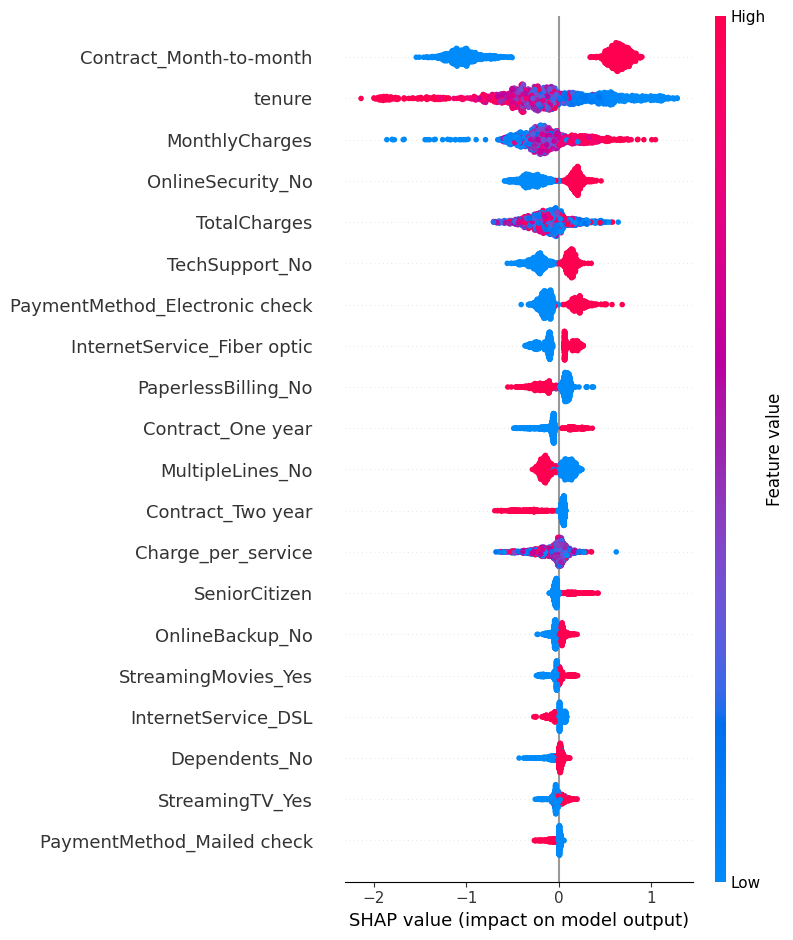

In [ ]:

!pip install shap

import shap
#Extracting the model from the pipeline
xgb_model = xgb_pipeline2.named_steps['classifier']

#We need the transformed data, so we just run the preprocessor on the X_test
preprocessor = xgb_pipeline2.named_steps['preprocessor']
X_test_transformed = preprocessor.transform(X_test_clean)

#Onehotencoded feature names
ohe_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = list(numeric_features)+list(ohe_feature_names)

#Creating SHAP explainer
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_transformed)

#plotting
plt.figure(figsize=(8,6))
shap.summary_plot(shap_values,X_test_transformed,feature_names=all_feature_names)

In [ ]:
import joblib

# Define the path in your mounted Google Drive
model_save_path = "/content/drive/MyDrive/ML_datasets/churn_xgb_pipeline_v1.pkl"

# Save the entire pipeline (includes Preprocessor + XGBoost)
joblib.dump(xgb_pipeline, model_save_path)

print(f"Success! Your pipeline is saved at: {model_save_path}")

Success! Your pipeline is saved at: /content/drive/MyDrive/ML_datasets/churn_xgb_pipeline_v1.pkl
